Data Visualisation
---

In this notebook we look at the data we are working with. It is sampled from a toy multi-variate Gaussian distribution setup by Malin Horstmann. See the README for directions on downloading it.

In [10]:
import pandas as pd
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt
hep.set_style("ATLAS")

In [11]:
BASE_PATH = "./dataframes/"

In [12]:
signal = pd.read_parquet(f"{BASE_PATH}/signal_10.parquet")
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

### Visualising the dataset

Before training the NN, lets take a look at what the "kinematics" of the final state look like.

Note how some variables might be more sensitive than others in discriminating signal from background. But our goal with SBI is to use all of the variables to build the model, including any high-dimensional correlations they might have.

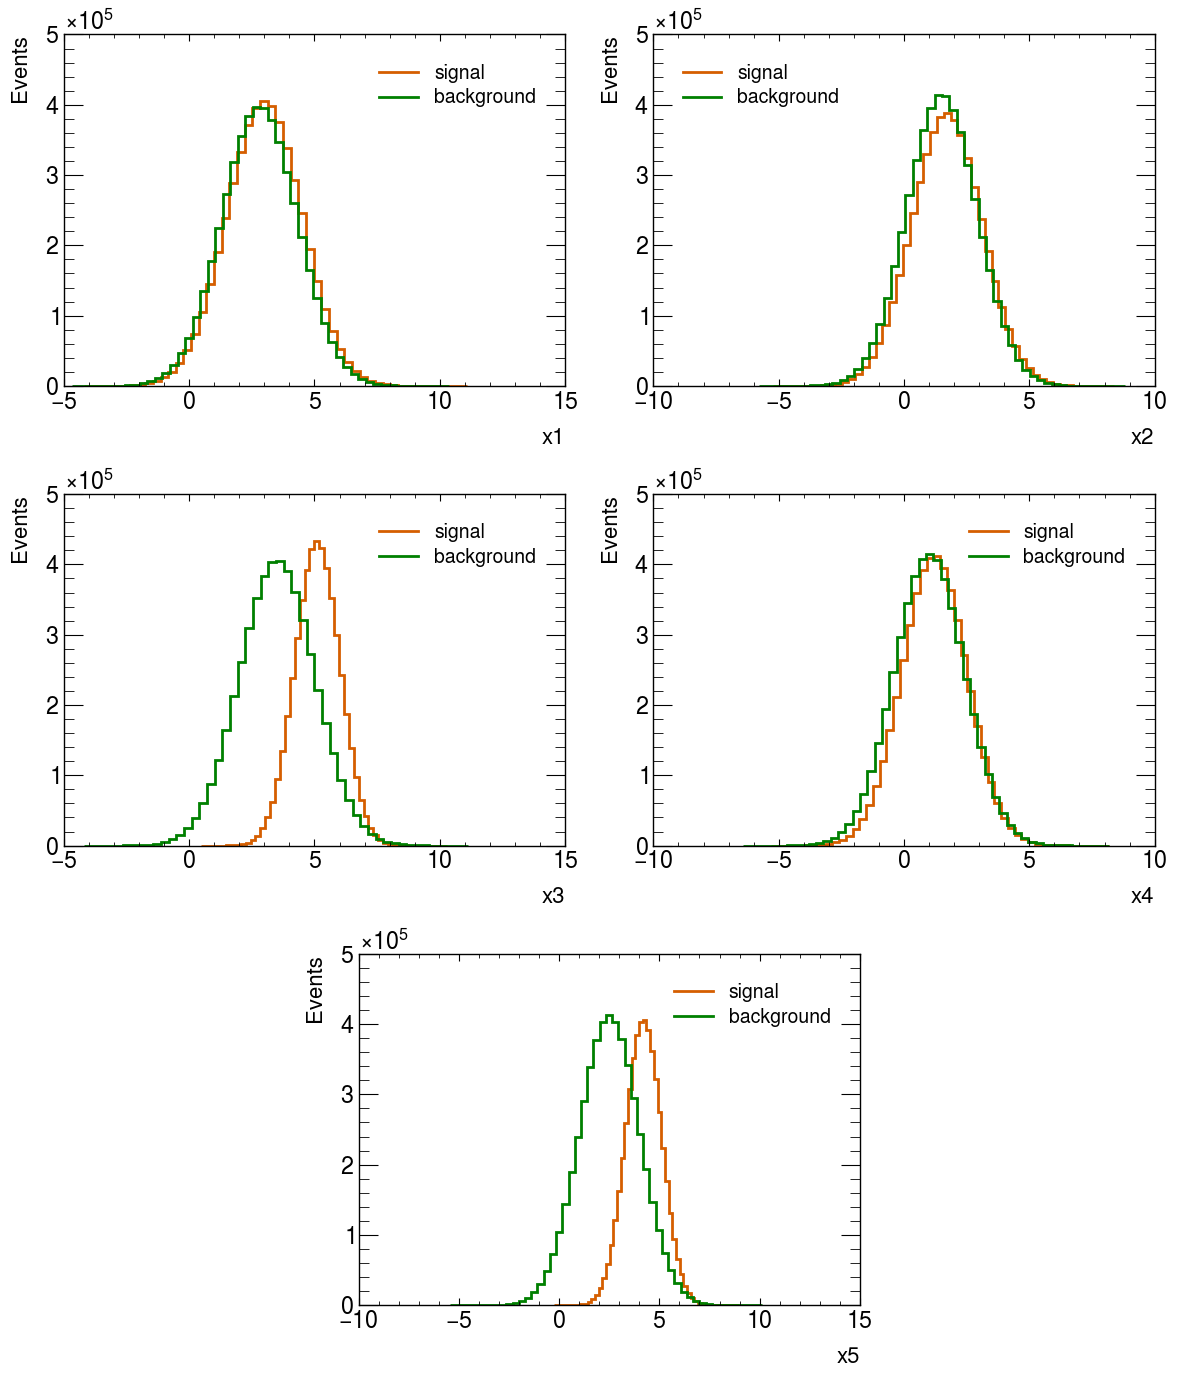

In [13]:
variables = ["x1", "x2", "x3", "x4", "x5"]

mosaic = [
    ["x1", "x1", "x2", "x2"],
    ["x3", "x3", "x4", "x4"],
    [".",  "x5", "x5", "."],
]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(12, 14))

for var in variables:
    ax = axes[var]

    x_sig = np.array(signal[var])
    h_sig, bins = np.histogram(x_sig, bins=50)
    hep.histplot(h_sig, bins, ax=ax, label="signal", linewidth=2.0)

    x_bkg = np.array(background[var])
    h_bkg, bins = np.histogram(x_bkg, bins=50)
    hep.histplot(h_bkg, bins, ax=ax, label="background", linewidth=2.0, color="green")

    ax.legend(fontsize=14)
    ax.set_xlabel(var, size=16)
    ax.set_ylabel("Events", size=16)

fig.tight_layout()
